# 03 — One feature: power law versus linear regression

We compare three deliberately simple calibrations on exactly the same raw point: a line on the
stored value, a line on `log1p(x)`, and an empirical power law. Training fits parameters;
validation selects the point; test and `test_extra` remain untouched until final evaluation.

## Software, models, and input parameter

`GAS` is the only central input. The notebook compares a line on the stored value, a line on
`log1p(x)`, and an empirical power law on the same raw point. NumPy fits their parameters.
All 48 allowed boundary points are ranked by power-law validation RMSE; test and `test_extra`
are used only after the point and model parameters have been fixed. Predictions are not clipped,
so model failure remains visible.

In [1]:
GAS = "hydrogen"

In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Day_02"
sys.path.insert(0, str(HERE.resolve()))
from dataset_pipeline import *

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unknown gas: {GAS}")
plt.style.use("seaborn-v0_8-whitegrid")
splits = prepare_splits("stored")

## 1. Three single-point models

In [3]:
def fit_affine(z, y):
    design = np.column_stack([z, np.ones(len(z))])
    slope, intercept = np.linalg.lstsq(design, y, rcond=None)[0]
    return float(slope), float(intercept)


def make_linear_raw(x_train, y_train):
    slope, intercept = fit_affine(x_train, y_train)
    return {
        "name": "Linear: stored value",
        "predict": lambda x: slope * np.asarray(x) + intercept,
        "parameters": {"slope": slope, "intercept": intercept},
    }


def make_linear_log1p(x_train, y_train):
    slope, intercept = fit_affine(np.log1p(x_train), y_train)
    return {
        "name": "Linear: log1p(x)",
        "predict": lambda x: slope * np.log1p(np.asarray(x)) + intercept,
        "parameters": {"slope": slope, "intercept": intercept},
    }


def make_power_law(x_train, y_train):
    if np.any(x_train <= 0) or np.any(y_train <= 0):
        raise ValueError("Power law requires positive x and target values")
    scale = float(np.median(x_train))
    exponent, log_amplitude = fit_affine(
        np.log(x_train / scale), np.log(y_train)
    )
    amplitude = float(np.exp(log_amplitude))

    def predict(x):
        log_prediction = (
            log_amplitude
            + exponent * np.log(np.asarray(x) / scale)
        )
        return np.exp(np.clip(log_prediction, -50, 50))

    return {
        "name": "Power Law",
        "predict": predict,
        "parameters": {
            "A": amplitude, "n": exponent, "scale": scale,
        },
    }


def metrics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        "R2": 1.0 - float(np.sum(residual ** 2)) / denominator,
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": float(np.mean(np.abs(residual))),
    }

The scale `s` is the training median. It improves numerical stability without adding
information. The power law is empirical because the dataset provides no separate reference
resistance R0.

## 2. Select a useful power-law point with training and validation only

In [4]:
candidates = temperature_boundary_points()
y_train = splits["train"]["targets"][GAS].astype(float)
y_val = splits["val"]["targets"][GAS].astype(float)
candidate_results = []

for point in candidates:
    x_train = splits["train"]["X"][:, 0, point.index].astype(float)
    x_val = splits["val"]["X"][:, 0, point.index].astype(float)
    model = make_power_law(x_train, y_train)
    val_prediction = model["predict"](x_val)
    candidate_results.append({
        "point": point,
        "model": model,
        "val_metrics": metrics(y_val, val_prediction),
    })

candidate_results.sort(
    key=lambda item: item["val_metrics"]["RMSE"]
)
selected_point = candidate_results[0]["point"]
print("Selected point:", selected_point)
print("The five best power-law points on validation:")
for item in candidate_results[:5]:
    m = item["val_metrics"]
    print(
        f"{item['point'].point_id:36s} "
        f"R2={m['R2']:+.4f}, RMSE={m['RMSE']:.4f}, "
        f"MAE={m['MAE']:.4f}"
    )

Selected point: BoundaryPoint(index=1319, temperature_c=350, phase='low', cycle_step=10, edge='end')
The five best power-law points on validation:
t350_low_step10_end_i1319            R2=+0.2398, RMSE=396.6234, MAE=317.8604
t400_high_step11_start_i1320         R2=+0.2339, RMSE=398.1644, MAE=319.4290
t400_high_step10_start_i1200         R2=+0.2275, RMSE=399.8189, MAE=320.4421
t325_low_step09_end_i1199            R2=+0.2256, RMSE=400.3164, MAE=320.5892
t375_low_step11_end_i1439            R2=+0.1860, RMSE=410.4254, MAE=331.0825


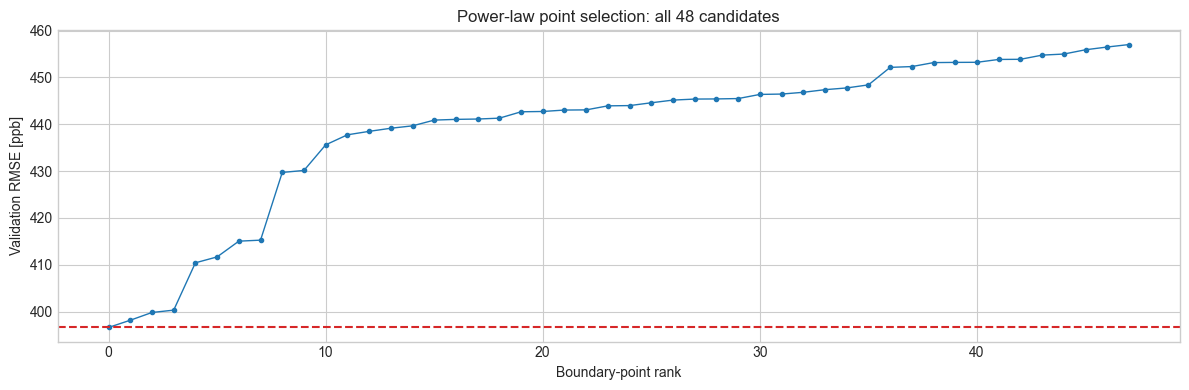

In [5]:
validation_rmse = [
    item["val_metrics"]["RMSE"]
    for item in candidate_results
]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(validation_rmse, marker="o", markersize=3, linewidth=1)
ax.axhline(validation_rmse[0], color="tab:red", linestyle="--")
ax.set(
    xlabel="Boundary-point rank",
    ylabel="Validation RMSE [ppb]",
    title="Power-law point selection: all 48 candidates",
)
plt.tight_layout()

## 3. Fit all three models on the same point

In [6]:
point_index = selected_point.index
x_train = splits["train"]["X"][:, 0, point_index].astype(float)
y_train = splits["train"]["targets"][GAS].astype(float)

models = [
    make_linear_raw(x_train, y_train),
    make_linear_log1p(x_train, y_train),
    make_power_law(x_train, y_train),
]
for model in models:
    print(model["name"], model["parameters"])

Linear: stored value {'slope': -0.5888955926915378, 'intercept': 20756.354078175922}
Linear: log1p(x) {'slope': -19688.227336547723, 'intercept': 206164.0548960537}
Power Law {'A': 1155.1182531482082, 'n': -18.538056427641, 'scale': 33120.0}


## 4. R², MSE, RMSE, and MAE on all four splits

In [7]:
results = {}
predictions = {}
for model in models:
    results[model["name"]] = {}
    predictions[model["name"]] = {}
    for split in SPLIT_NAMES:
        x = splits[split]["X"][:, 0, point_index].astype(float)
        y = splits[split]["targets"][GAS].astype(float)
        prediction = model["predict"](x)
        predictions[model["name"]][split] = prediction
        results[model["name"]][split] = metrics(y, prediction)

print("Model                     Split             R2"
      "           MSE          RMSE           MAE")
for model in models:
    name = model["name"]
    for split in SPLIT_NAMES:
        m = results[name][split]
        print(
            f"{name:27s} {split:10s} {m['R2']:11.4f} "
            f"{m['MSE']:13.4f} {m['RMSE']:13.4f} "
            f"{m['MAE']:13.4f}"
        )
    print()

Model                     Split             R2           MSE          RMSE           MAE
Linear: stored value        train           0.3685   132510.0878      364.0194      300.5594
Linear: stored value        val             0.2535   154474.1558      393.0320      313.1408
Linear: stored value        test            0.3223   145933.5760      382.0125      312.9035
Linear: stored value        test_extra     -1.8811   613031.3342      782.9632      659.3990

Linear: log1p(x)            train           0.3696   132271.2914      363.6912      300.0476
Linear: log1p(x)            val             0.2536   154458.4237      393.0120      313.1505
Linear: log1p(x)            test            0.3215   146095.2059      382.2240      312.7745
Linear: log1p(x)            test_extra     -1.9800   634066.2867      796.2828      672.5639

Power Law                   train           0.3602   134237.1128      366.3838      301.5106
Power Law                   val             0.2398   157310.1447      39

## 5. Direct metric comparison

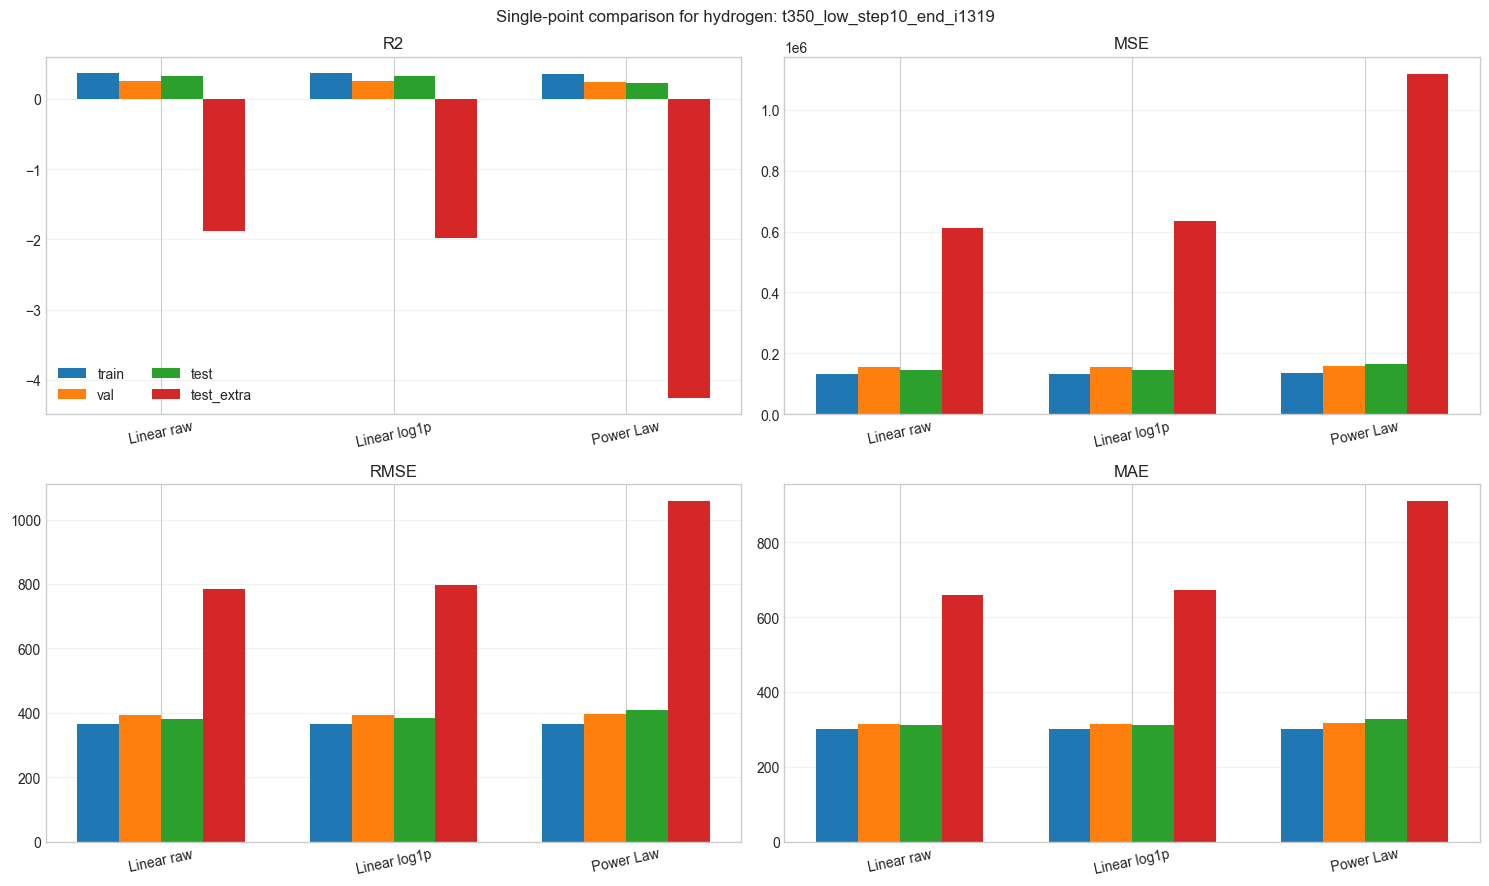

In [8]:
metric_names = ("R2", "MSE", "RMSE", "MAE")
split_colors = {
    "train": "tab:blue", "val": "tab:orange",
    "test": "tab:green", "test_extra": "tab:red",
}
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
positions = np.arange(len(models))
width = 0.18
for ax, metric_name in zip(axes.ravel(), metric_names):
    for offset, split in enumerate(SPLIT_NAMES):
        values = [
            results[model["name"]][split][metric_name]
            for model in models
        ]
        ax.bar(
            positions + (offset - 1.5) * width, values,
            width=width, label=split, color=split_colors[split]
        )
    ax.set_title(metric_name)
    ax.set_xticks(positions)
    ax.set_xticklabels(
        ["Linear raw", "Linear log1p", "Power Law"],
        rotation=12
    )
    ax.grid(axis="y", alpha=0.25)
axes[0, 0].legend(ncol=2)
fig.suptitle(
    f"Single-point comparison for {GAS}: {selected_point.point_id}"
)
plt.tight_layout()

## 6. Training data and learned curves

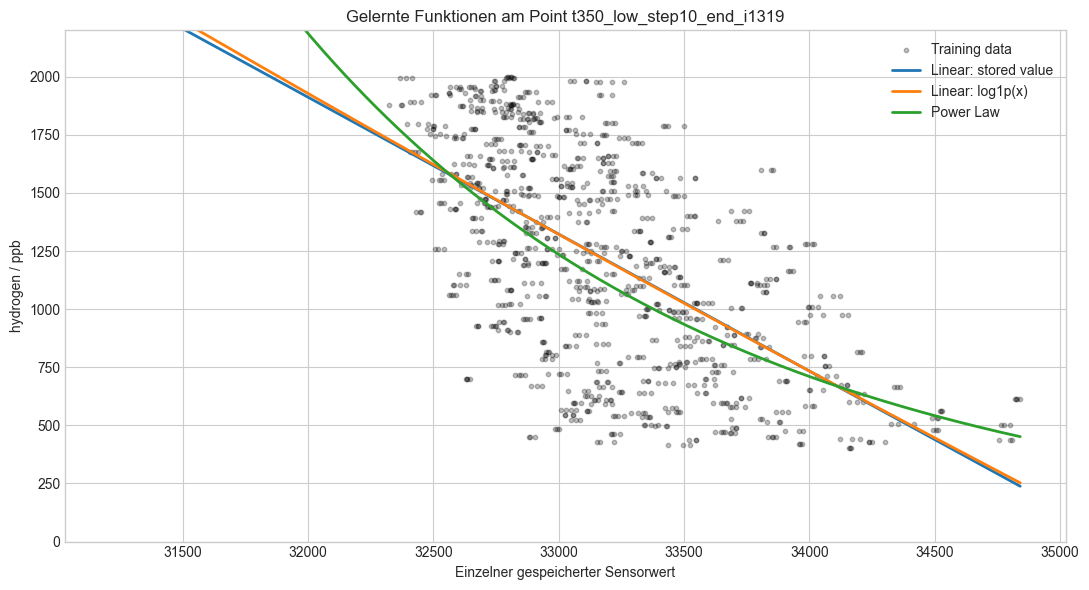

In [9]:
all_x = np.concatenate([
    splits[split]["X"][:, 0, point_index]
    for split in SPLIT_NAMES
])
grid = np.linspace(all_x.min(), all_x.max(), 500)
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(
    x_train, y_train, s=10, alpha=0.25,
    color="black", label="Training data"
)
for model in models:
    ax.plot(
        grid, model["predict"](grid), linewidth=2,
        label=model["name"]
    )
target_max = max(
    float(splits[split]["targets"][GAS].max())
    for split in SPLIT_NAMES
)
ax.set_ylim(bottom=0, top=target_max * 1.10)
ax.set(
    xlabel="Einzelner gespeicherter Sensorwert",
    ylabel=f"{GAS} / ppb",
    title=f"Gelernte Funktionen am Point {selected_point.point_id}"
)
ax.legend()
plt.tight_layout()

## 7. Parity plots for every model and split

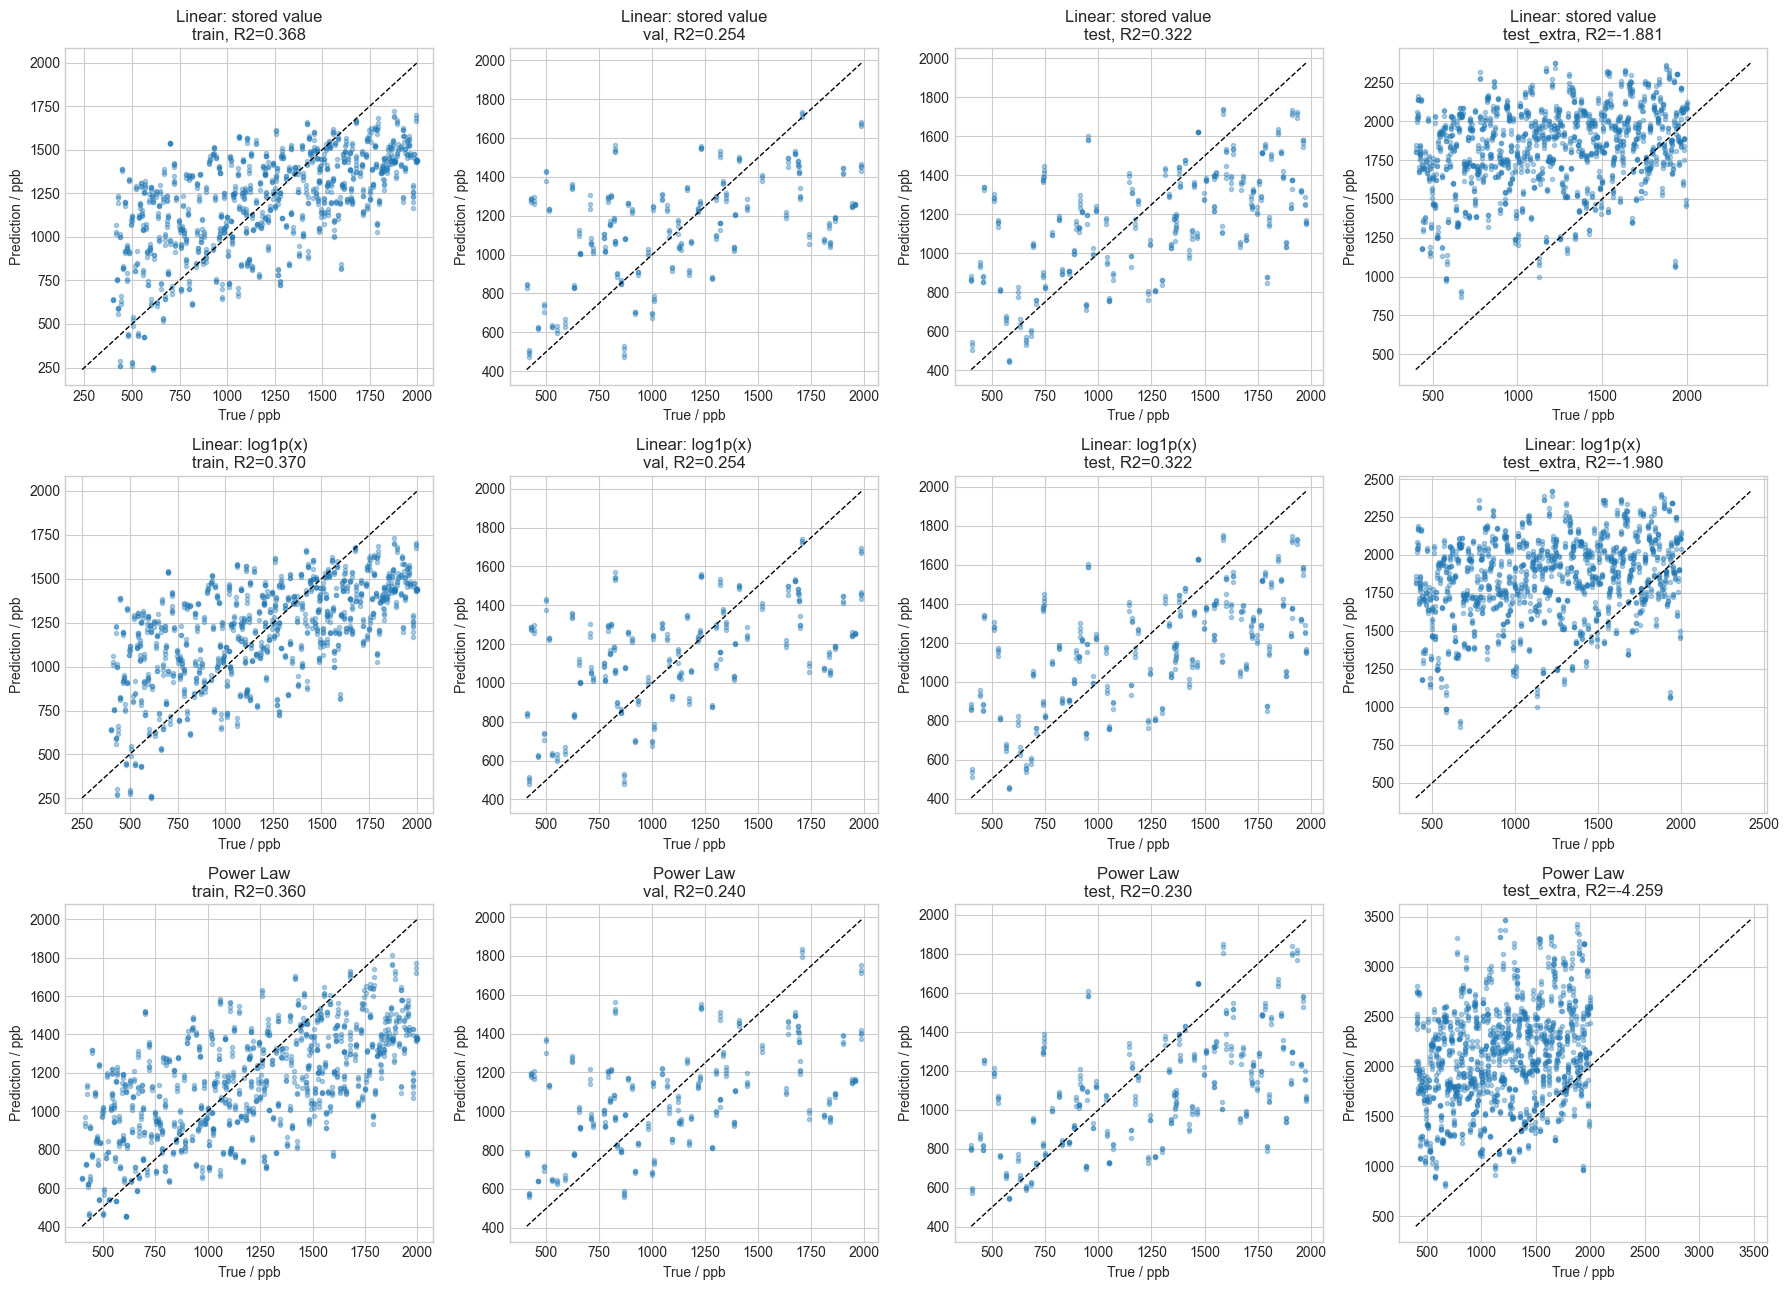

In [10]:
fig, axes = plt.subplots(
    len(models), len(SPLIT_NAMES), figsize=(18, 13)
)
for row, model in enumerate(models):
    name = model["name"]
    for column, split in enumerate(SPLIT_NAMES):
        ax = axes[row, column]
        y = splits[split]["targets"][GAS].astype(float)
        pred = predictions[name][split]
        ax.scatter(y, pred, s=9, alpha=0.35)
        finite_pred = pred[np.isfinite(pred)]
        low = min(float(y.min()), float(finite_pred.min()))
        high = max(float(y.max()), float(finite_pred.max()))
        ax.plot([low, high], [low, high], "k--", linewidth=1)
        ax.set_title(
            f"{name}\n{split}, "
            f"R2={results[name][split]['R2']:.3f}"
        )
        ax.set_xlabel("True / ppb")
        ax.set_ylabel("Prediction / ppb")
plt.tight_layout()

The regular test measures interpolation to new UGMs within the first two concentration
ranges. `test_extra` measures extrapolation into the final range. Good interpolation therefore
does not guarantee good extrapolation.